# Visual EDA — Noise Analysis & Augmentation Comparison

This notebook combines two visual exploratory analyses:

1. **Background Noise Study** — Compares spectrogram characteristics of clean VoxPopuli recordings vs. local microphone recordings to inspect the influence of background noise.
2. **Augmentation Visual Comparison** — Shows original class_1 spectrograms alongside their three augmented variants (Time Mask, Frequency Mask, Gaussian Noise) to document the image-level transformations used during training.

> Run all cells from the **project root directory** (the folder containing `spectrograms/` and `data_preprocess/`).

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from data_preprocess.audio_utils import time_mask, freq_mask, add_noise_to_image

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

In [2]:
# ── Shared configuration ──
CLASS0_DIR  = 'spectrograms/class_0'
CLASS1_DIR  = 'spectrograms/class_1'
PLOTS_DIR   = 'plots'
IMG_SIZE    = (128, 128)   # all images are resized to this before analysis
RANDOM_SEED = 42

os.makedirs(PLOTS_DIR, exist_ok=True)
print('Configuration OK')

Configuration OK


---
## Part 1 — Background Noise Study

The requirement states: *"The obvious issue hindering the recognition capability is background noise. Its influence must be studied in the report and appropriate codes must be prepared to inspect this issue."*

We compare three groups of spectrograms:

| Group | Source | Characteristics |
|---|---|---|
| `class_0 — VoxPopuli (clean)` | European Parliament recordings | Studio-quality, low noise floor |
| `class_0 — Local mic (noisy)` | Laptop microphone (`my_records/`) | Real-world ambient noise |
| `class_1 — Target speakers` | VoxPopuli subset | Same domain as VoxPopuli class_0 |

The local recordings have the prefix `local_record_` in their filename (injected by `get_data.py`). All other class_0 files have a numeric speaker-ID prefix.

In [3]:
def load_image_list(directory, file_list):
    """
    Loads a specific list of PNG filenames from a directory as normalised
    grayscale numpy arrays of shape (H, W) with values in [0, 1].

    Args:
        directory (str):       Path to the spectrogram directory.
        file_list (list[str]): Filenames to load from that directory.

    Returns:
        np.ndarray: Array of shape (N, H, W).
    """
    arrays = []
    for fname in file_list:
        try:
            img = Image.open(os.path.join(directory, fname)).convert('L')
            img = img.resize(IMG_SIZE)
            arrays.append(np.array(img, dtype=np.float32) / 255.0)
        except Exception as e:
            print(f'  Skipping {fname}: {e}')
    return np.stack(arrays, axis=0) if arrays else np.empty((0, *IMG_SIZE))


# ── Separate class_0 files by origin ──
all_c0 = sorted(
    f for f in os.listdir(CLASS0_DIR)
    if f.endswith('.png') and '_aug_' not in f
) if os.path.exists(CLASS0_DIR) else []

vox_files   = [f for f in all_c0 if not f.startswith('local_record_')]
local_files = [f for f in all_c0 if f.startswith('local_record_')]
class1_files = sorted(
    f for f in os.listdir(CLASS1_DIR)
    if f.endswith('.png') and '_aug_' not in f
) if os.path.exists(CLASS1_DIR) else []

vox_data    = load_image_list(CLASS0_DIR, vox_files)
local_data  = load_image_list(CLASS0_DIR, local_files)
class1_data = load_image_list(CLASS1_DIR, class1_files)

print(f'VoxPopuli (clean) : {vox_data.shape[0]:>5} images')
print(f'Local mic (noisy) : {local_data.shape[0]:>5} images')
print(f'Target (class_1)  : {class1_data.shape[0]:>5} images')

groups = {
    'class_0 — VoxPopuli (clean)': vox_data,
    'class_0 — Local mic (noisy)': local_data,
    'class_1 — Target speakers':   class1_data,
}
# Drop empty groups
groups = {k: v for k, v in groups.items() if v.shape[0] > 0}

VoxPopuli (clean) :  2058 images
Local mic (noisy) :     0 images
Target (class_1)  :    32 images


### Analysis 1 — Mean Spectrogram Images

The pixel-wise mean spectrogram for each group reveals systematic differences in spectral shape introduced by noise. A high noise floor shows up as uniformly elevated pixel values across all frequency bands.

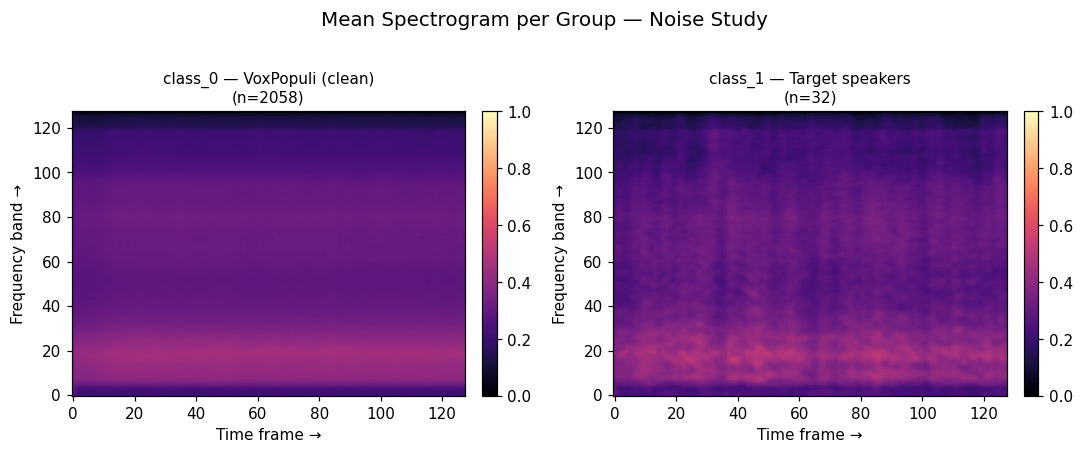

Saved → plots/noise_mean_spectrograms.png


In [4]:
n = len(groups)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, (label, data) in zip(axes, groups.items()):
    mean_img = data.mean(axis=0)
    im = ax.imshow(mean_img, cmap='magma', aspect='auto', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'{label}\n(n={data.shape[0]})', fontsize=10)
    ax.set_xlabel('Time frame →')
    ax.set_ylabel('Frequency band →')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Mean Spectrogram per Group — Noise Study', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/noise_mean_spectrograms.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plots/noise_mean_spectrograms.png')

### Analysis 2 — Pixel Intensity Distribution

A histogram of all pixel values shows whether noisy recordings have a systematically different energy distribution. A heavy left tail (many dark pixels) indicates silence or a low-energy noise floor; a flatter or right-shifted distribution suggests more uniform broadband noise.

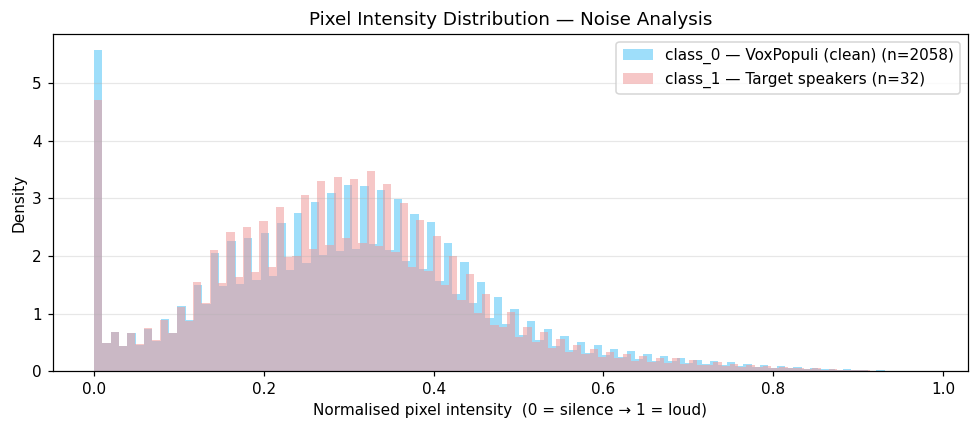

Saved → plots/noise_intensity_distribution.png

Group                                  Mean     Std   Median
------------------------------------------------------------
class_0 — VoxPopuli (clean)          0.2974  0.1637   0.2941
class_1 — Target speakers            0.2928  0.1563   0.2902


In [5]:
colors = ['#4fc3f7', '#ef9a9a', '#a5d6a7']

fig, ax = plt.subplots(figsize=(9, 4))
for (label, data), color in zip(groups.items(), colors):
    ax.hist(data.flatten(), bins=100, alpha=0.55,
            label=f'{label} (n={data.shape[0]})', color=color, density=True)

ax.set_xlabel('Normalised pixel intensity  (0 = silence → 1 = loud)')
ax.set_ylabel('Density')
ax.set_title('Pixel Intensity Distribution — Noise Analysis')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/noise_intensity_distribution.png', dpi=120)
plt.show()
print('Saved → plots/noise_intensity_distribution.png')

# Summary statistics
print(f"\n{'Group':<35} {'Mean':>7} {'Std':>7} {'Median':>8}")
print('-' * 60)
for label, data in groups.items():
    p = data.flatten()
    print(f'{label:<35} {p.mean():>7.4f} {p.std():>7.4f} {np.median(p):>8.4f}')

### Analysis 3 — Per-Time-Frame Energy Profile

Averaging pixel intensity at each time-frame column across all samples and frequency rows gives an energy envelope for the full 4-second segment. A consistently elevated baseline (noise floor) in the local microphone group confirms broadband ambient noise captured by the laptop mic.

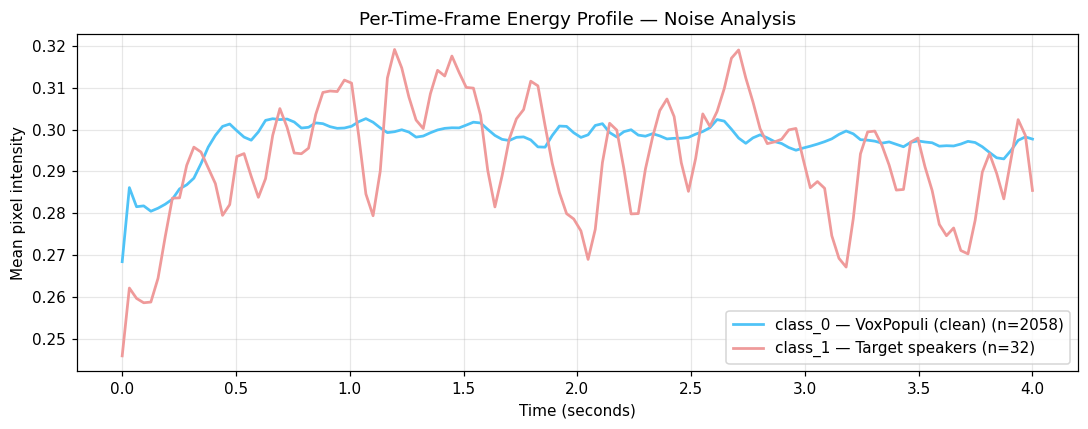

Saved → plots/noise_energy_profile.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

for (label, data), color in zip(groups.items(), colors):
    # Mean over samples (axis 0) and frequency rows (axis 1) → shape (W,)
    profile   = data.mean(axis=(0, 1))
    time_axis = np.linspace(0, 4, len(profile))   # 4-second segments
    ax.plot(time_axis, profile, label=f'{label} (n={data.shape[0]})',
            color=color, linewidth=1.8)

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Mean pixel intensity')
ax.set_title('Per-Time-Frame Energy Profile — Noise Analysis')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/noise_energy_profile.png', dpi=120)
plt.show()
print('Saved → plots/noise_energy_profile.png')

---
## Part 2 — Augmentation Visual Comparison

Data augmentation is applied to the minority class (class_1) to improve its representation during training without destroying the natural class imbalance.

Three image-level augmentations are used:

| Augmentation | Effect | Purpose |
|---|---|---|
| **Time Mask** | Vertical black bar over random time frames | Simulates missing audio frames / recording gaps |
| **Frequency Mask** | Horizontal black bar over random frequency bands | Simulates microphone frequency response variation |
| **Gaussian Noise** | Random pixel-level noise | Simulates sensor noise and recording variability |

The grid below shows the same original spectrogram alongside each augmented variant.

In [7]:
def load_original_samples(directory, n=4, seed=42):
    """
    Randomly samples n original (non-augmented) PNG files from a directory.

    Args:
        directory (str): Spectrogram directory path.
        n (int):         Number of images to sample.
        seed (int):      Random seed for reproducibility.

    Returns:
        list[tuple[str, PIL.Image.Image]]: List of (filename, RGB image) pairs.
    """
    random.seed(seed)
    files = [
        f for f in os.listdir(directory)
        if f.endswith('.png') and '_aug_' not in f
    ]
    chosen = random.sample(files, min(n, len(files)))
    return [(f, Image.open(os.path.join(directory, f)).convert('RGB'))
            for f in sorted(chosen)]


def augment_all(img):
    """
    Applies each augmentation type to a PIL Image.

    Args:
        img (PIL.Image.Image): Original spectrogram image.

    Returns:
        list[tuple[str, PIL.Image.Image]]: (label, augmented_image) pairs.
    """
    random.seed(7)
    return [
        ('Original',       img.copy()),
        ('Time Mask',      time_mask(img.copy(), max_mask_width=20)),
        ('Frequency Mask', freq_mask(img.copy(), max_mask_width=20)),
        ('Gaussian Noise', add_noise_to_image(img.copy(), factor=0.04)),
    ]


if not os.path.exists(CLASS1_DIR):
    print(f'Directory not found: {CLASS1_DIR}. Run main.py first.')
else:
    examples = load_original_samples(CLASS1_DIR, n=4, seed=RANDOM_SEED)
    print(f'Loaded {len(examples)} class_1 examples:')
    for fname, _ in examples:
        print(f'  {fname}')

Loaded 4 class_1 examples:
  197733.wav_2.png
  28176.wav_2.png
  37790.wav_3.png
  37790.wav_5.png


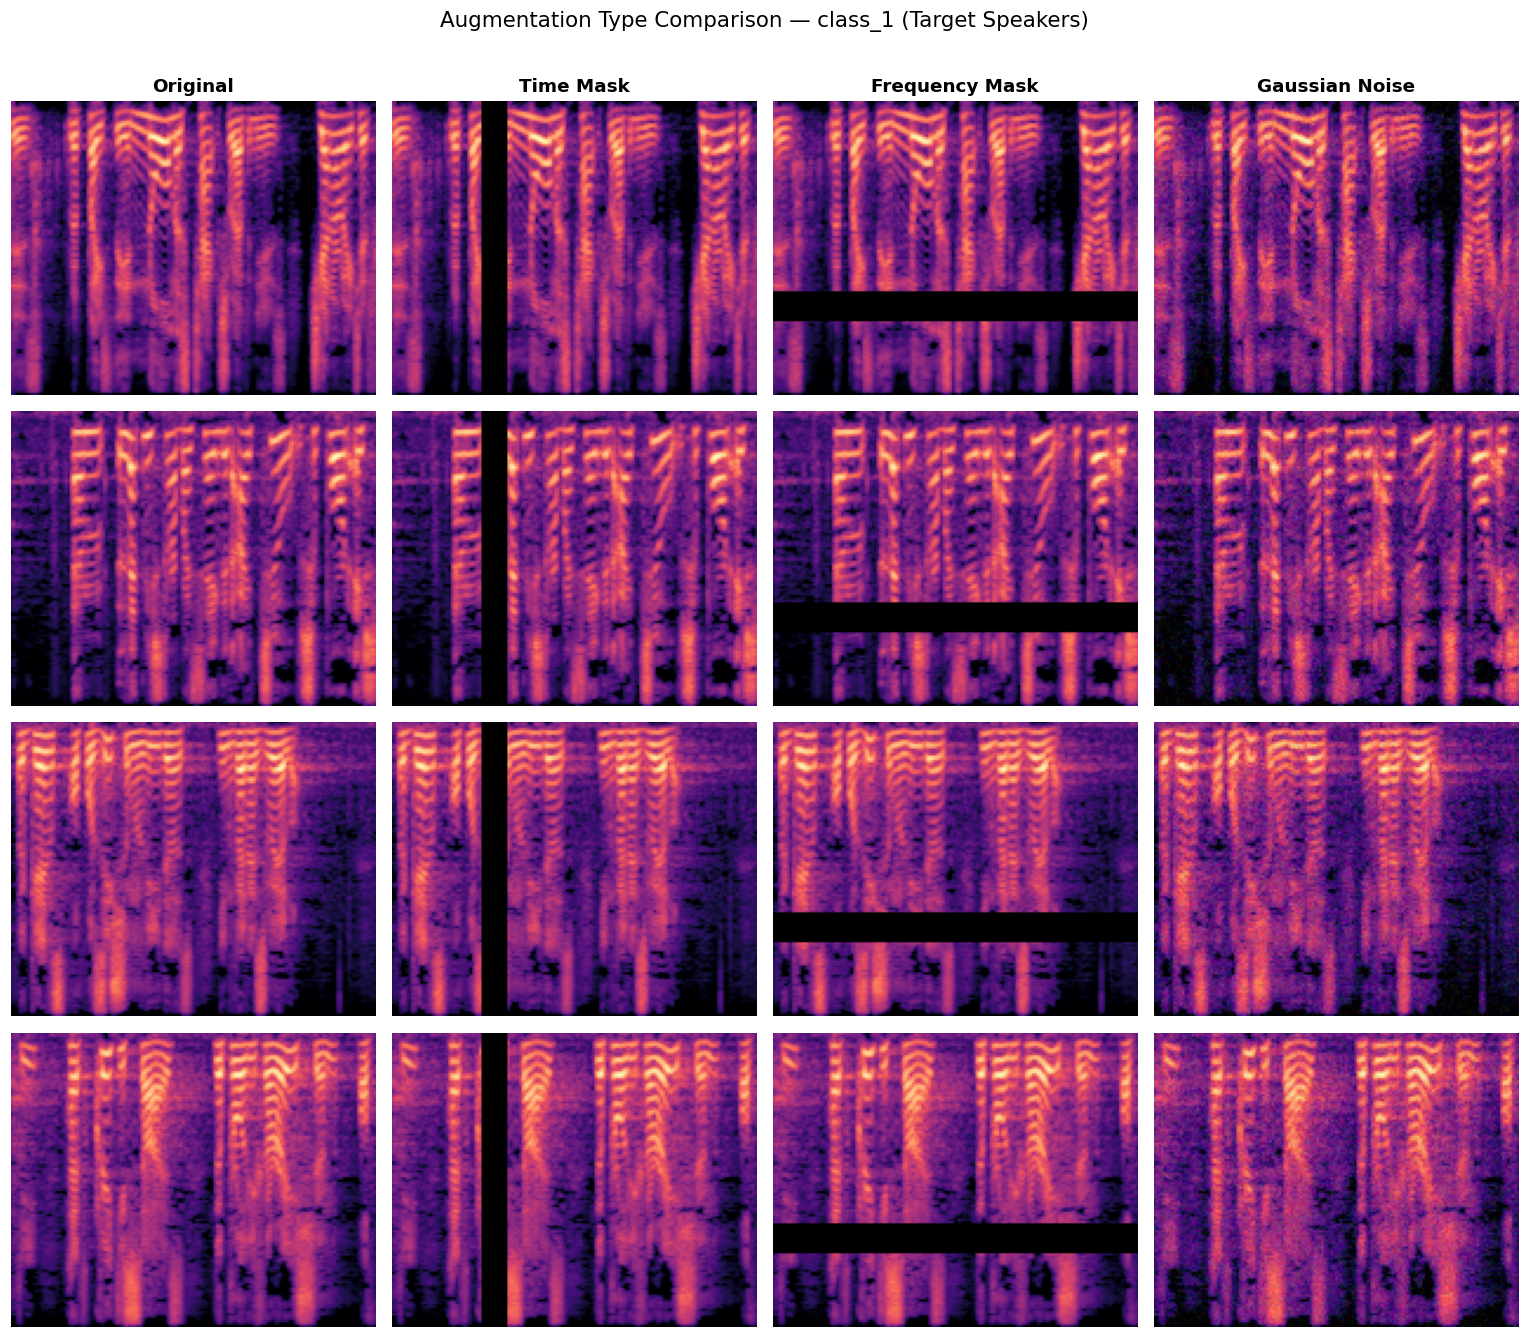

Saved → plots/augmentation_comparison.png


In [8]:
aug_labels = [label for label, _ in augment_all(examples[0][1])]
n_rows = len(examples)
n_cols = len(aug_labels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows), squeeze=False)

for row_idx, (fname, orig_img) in enumerate(examples):
    speaker_id  = fname.split('_')[0]
    aug_versions = augment_all(orig_img)

    for col_idx, (aug_label, aug_img) in enumerate(aug_versions):
        ax = axes[row_idx][col_idx]
        ax.imshow(np.array(aug_img), aspect='auto')
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(aug_label, fontsize=12, fontweight='bold', pad=6)
        if col_idx == 0:
            ax.set_ylabel(f'Speaker {speaker_id}', fontsize=9)

fig.suptitle('Augmentation Type Comparison — class_1 (Target Speakers)',
             fontsize=14, y=1.01)
plt.tight_layout()

out_path = f'{PLOTS_DIR}/augmentation_comparison.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')